# Modeling Power Outages by County in Maine

The goal of this notebook is to use sktime to predict customers.out in the counties in Maine.

Maine has only sixteen counties with a wide range of topography and population. 
If we are able to set up hierarchical methods for ME, we should be able to scale up to the entire US.

The outline of the notebook is:
- Setup
    - Import packages
    - Load and arrange the data
    - Set the y-variable
    - Set the features
    - Restrict to a smaller set for testing purposes
- EDA
    - Graph customers.out as time series for each county
    - Make ACF graphs for each county to identify potential seasonality
    - Check for stationarity
    - Make PACF graphs to suggest model order
- Set up the expanding window forecaster
- Setting up Forecasters
    - KNeighbors
    - TimeSeriesForest
    - XGBooxt
- Analysis
    - Use the built-in evaluate function with customers_out
    - Use custom code to evaluate max customers out over the next 4 intervals

## SKTime Guides

The basic sktime workflow is:
1. Preparation of the data
2. Specification of the time points for which forecasts are requested. This uses a numpy.array or the ForecastingHorizon object.
3. Specification and instantiation of the forecaster. This follows a scikit-learn-like syntax; forecaster objects follow the familiar scikit-learn BaseEstimator interface.
4. Fitting the forecaster to the data, using the forecaster's fit method
5. Making a forecast, using the forecaster's predict method

Following guides at:
- https://github.com/sktime/sktime/blob/main/examples/01_forecasting.ipynb
- https://www.sktime.net/en/latest/examples/01c_forecasting_hierarchical_global.html

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sktime.utils.plotting import plot_series

from sktime.split import temporal_train_test_split
from sktime.split import ExpandingWindowSplitter

from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.arima import ARIMA
from sktime.forecasting.naive import NaiveForecaster
from sktime.forecasting.sarimax import SARIMAX
from sktime.forecasting.varmax import VARMAX

from sktime.forecasting.compose import make_reduction
from sktime.forecasting.compose import ForecastingPipeline
from sktime.forecasting.model_evaluation import evaluate

from sktime.regression.compose import RegressorPipeline
from sktime.regression.distance_based import KNeighborsTimeSeriesRegressor
from sktime.regression.interval_based import TimeSeriesForestRegressor

# Note that we'll need to install darts for xgb to work:
# conda install -c conda-forge -c pytorch u8darts-all
from sktime.forecasting.darts import DartsXGBModel
from sktime.forecasting.darts import DartsLinearRegressionModel


from sklearn.preprocessing import StandardScaler

from sktime.transformations.series.adapt import TabularToSeriesAdaptor

from sktime.performance_metrics.forecasting import mean_absolute_percentage_error
from sktime.performance_metrics.forecasting import MeanAbsolutePercentageError
from sktime.performance_metrics.forecasting import MeanSquaredError

# There is a futurewarning from sklearn that will be addressed eventually in sktime; suppressing it for now.
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Load and Arrange the Data

We'll load the dataset with eaglei, noaa, era5, county-level, and engineered variables

We'll restrict to our training set (pre-2022)

For now, we'll also restrict ourselves to Maine, which has just 16 counties--a sufficient number to let us try out the techniques before deploying on the entire country

In [2]:
#Load the engineered data
df = pd.read_parquet('../Data/Merged_Data/eaglei_noaa_era5_engineered.parquet')

In [3]:
# Sort df
df = df.sort_values(by=['fips_code', 'datetime'])

# Restrict df to years prior to 2022
# For now, we'll just focus on Maine
df = df[df['STUSPS'] == 'ME']
df = df[df['YEAR'] < 2022]

# The first nonzero entry for customers_out in Maine was November 2nd, 2014
df = df[df['datetime'] > '2014-11-01']

# Use fips_code and datetime as indices
df = df.set_index(['fips_code', 'datetime'])

#Sort df
#df = df.sort_index()

## Set the y-variable (customers_out)

We'll need to do a bit of work with the index to make it compatible with sktime.
Specifically, we'll need to recreate the multiindex and imbue it with a frequency

In [4]:
y = df['customers_out']

#Set the multiindex on y
y = y.reset_index()

#Use fips_code and datetime as a multiindex on y
y = y.set_index(['fips_code', 'datetime'])

#Sort y
y = y.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
y.index = y.index.set_levels(y.index.levels[1].to_period('6h'), level=1)

# Set the features

In [5]:
# Create a new variable dividing POPULATION divided by AREA
df['density'] = df['POPULATION'] / df['AREA']

# Note: Not currently including Subregion b/c we'd need to convert to a dummy variable

features = ['Pct_Buried_Lines','centroid_longitude','centroid_latitude','density',
       'event_count SnowIce',
       'event_count Flood', 'event_count Storm', 'event_count Hurricane',
       'event_count Heat', 'event_count Fire', 'event_count Wind',
       'event_count Ocean', 'event_count Other', 't2m', 'sf', 'tp', 't2m_mean',
       't2m_max', 'sf_mean', 'sf_max', 'tp_mean', 'tp_max', 'wind_speed',
       'neighbor_mean_wind_speed', 'neighbor_max_wind_speed', 'sf_12h',
       'sf_24h', 'tp_12h', 'tp_24h']


X = df[features]

#Set the multiindex on y and X
X = X.reset_index()

#Use fips_code and datetime as a multiindex
X = X.set_index(['fips_code', 'datetime'])

#Sort
X = X.sort_index()

# Note that datetime doesn't have an embedded frequency; we'll need to set this manually
#Convert DatetimeIndex to PeriodIndex with 6-hour frequency
X.index = X.index.set_levels(X.index.levels[1].to_period('6h'), level=1)

## Restrict to a smaller set for testing

In [6]:
# Restrict to a smaller data set for testing purposes
y_small = y.groupby(level=0).tail(1000)
X_small = X.groupby(level=0).tail(1000)

# EDA

## Graphing the Data

We'll start by making some plots of the data to get a sense of the sparsity of the data

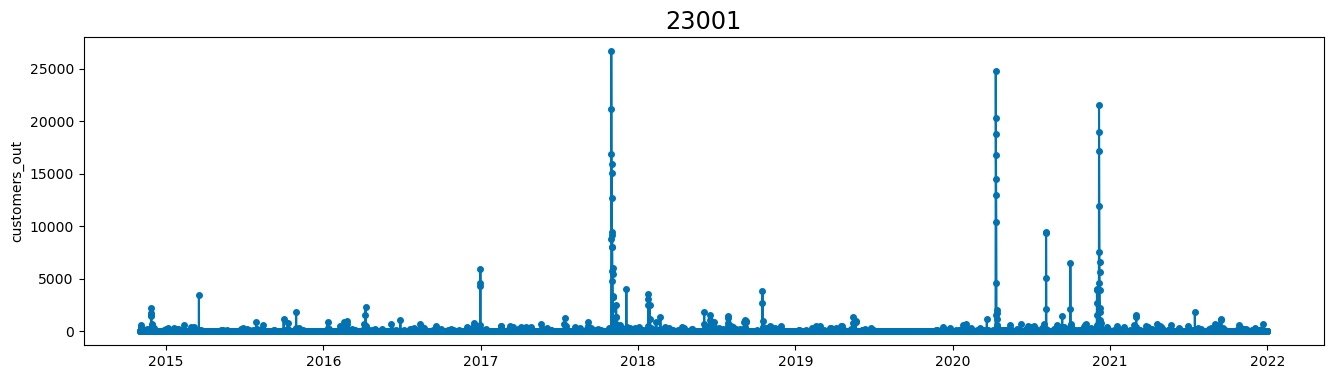

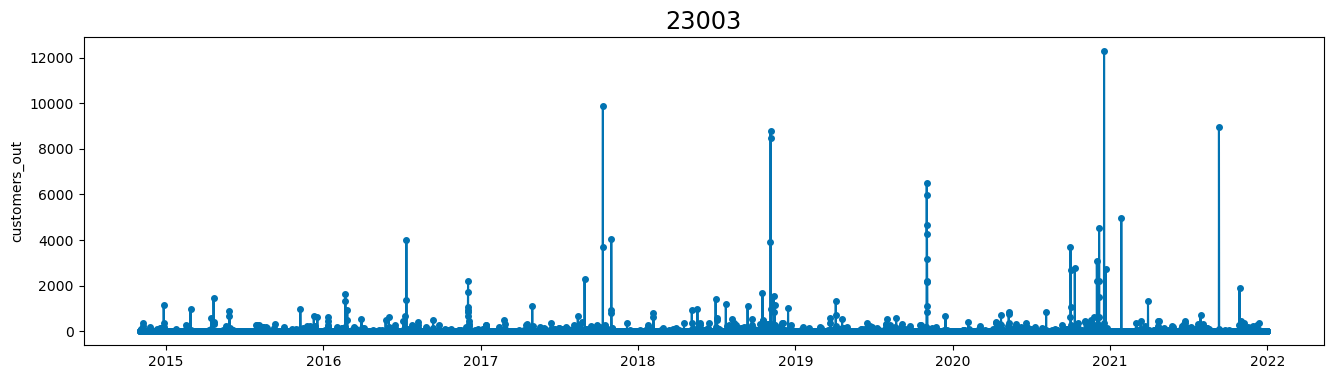

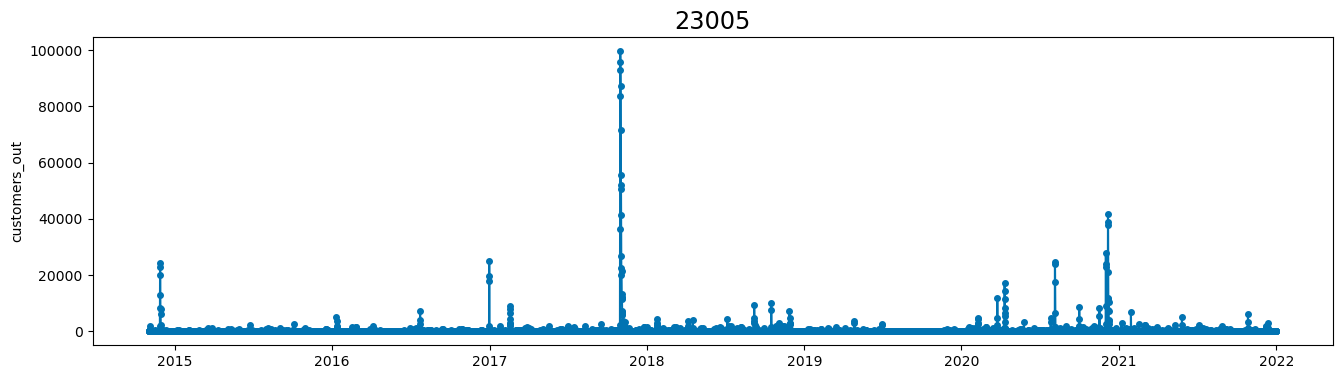

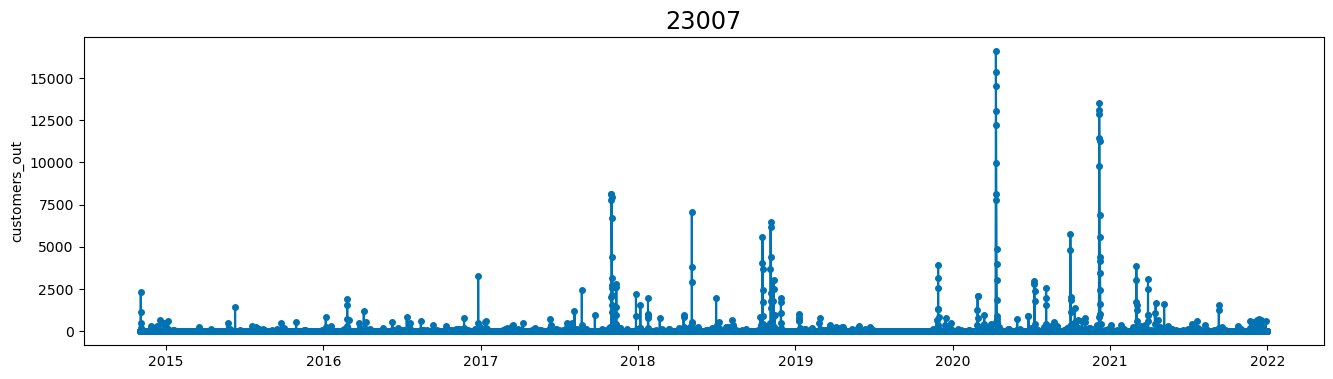

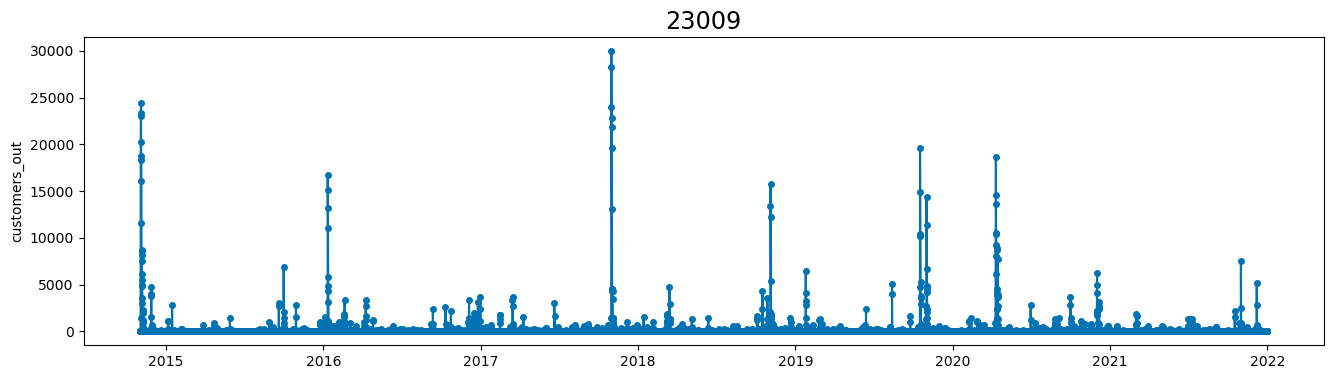

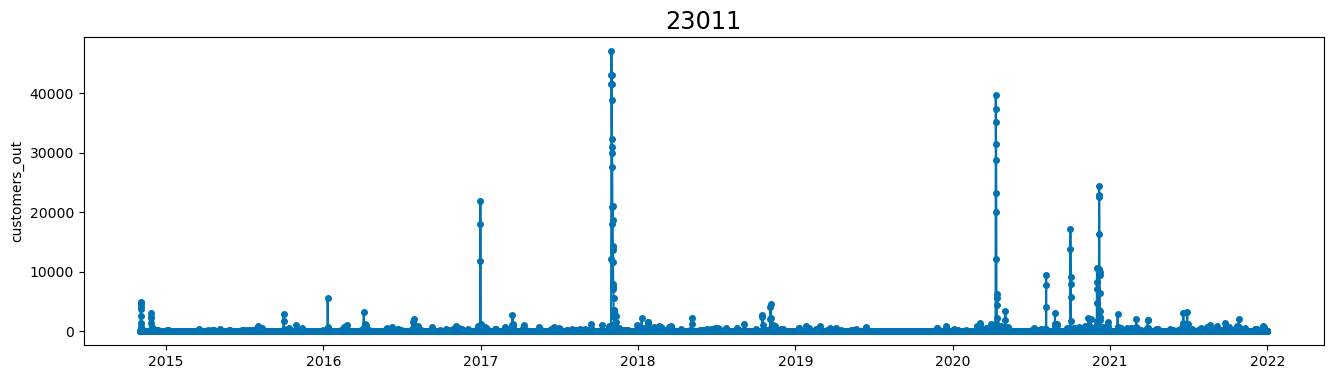

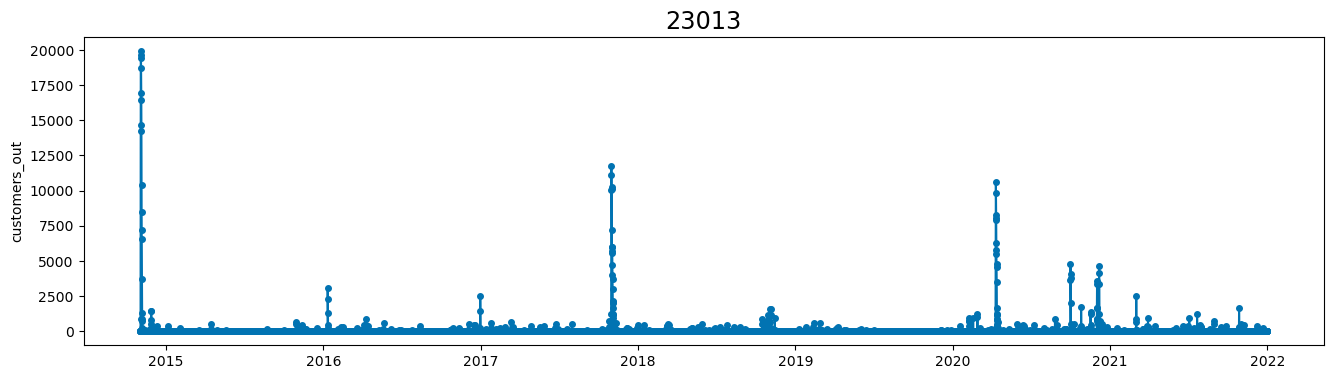

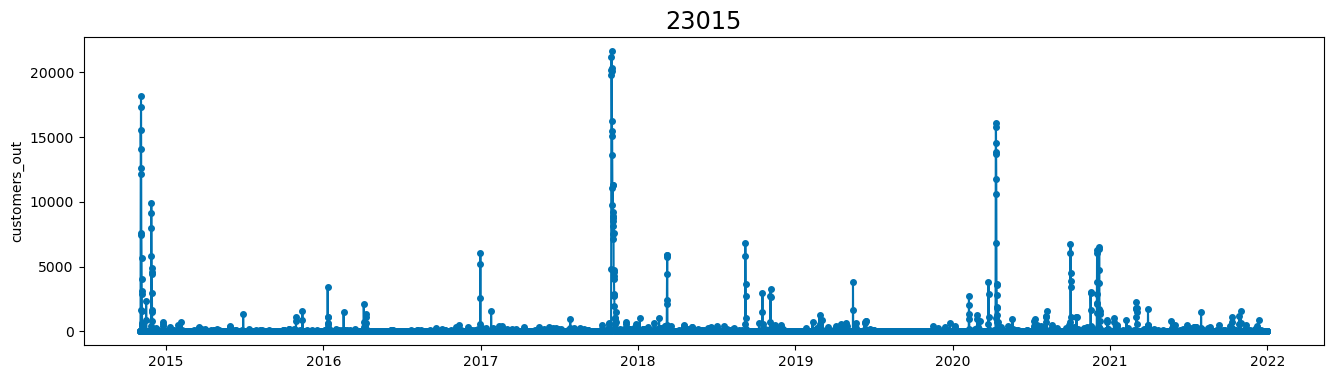

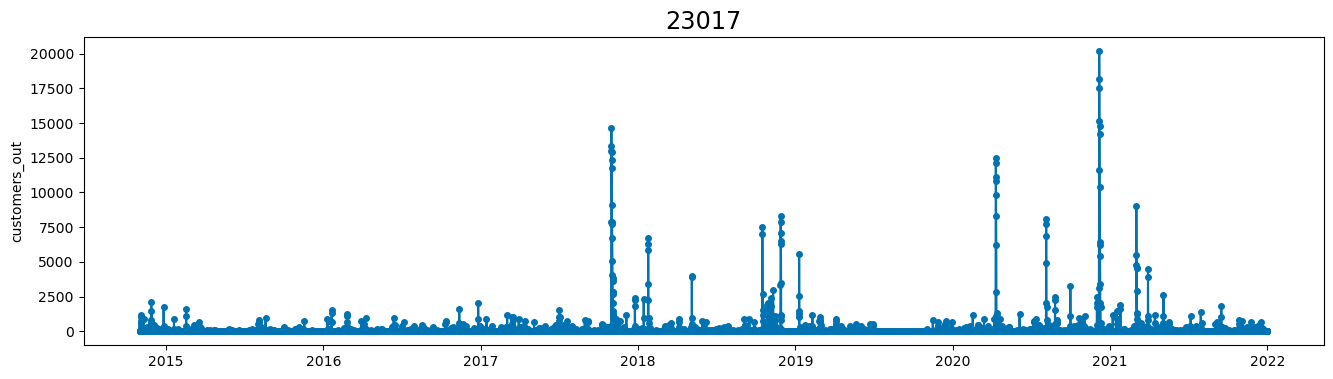

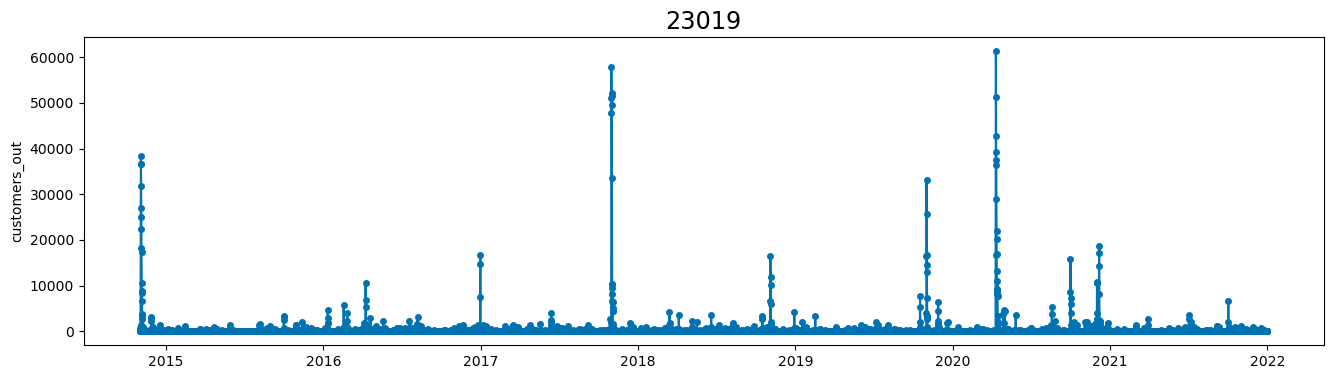

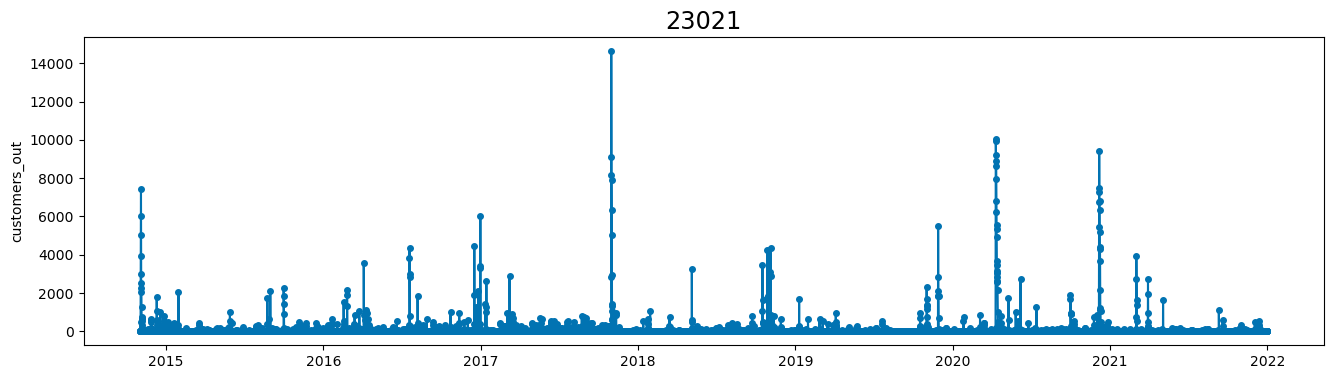

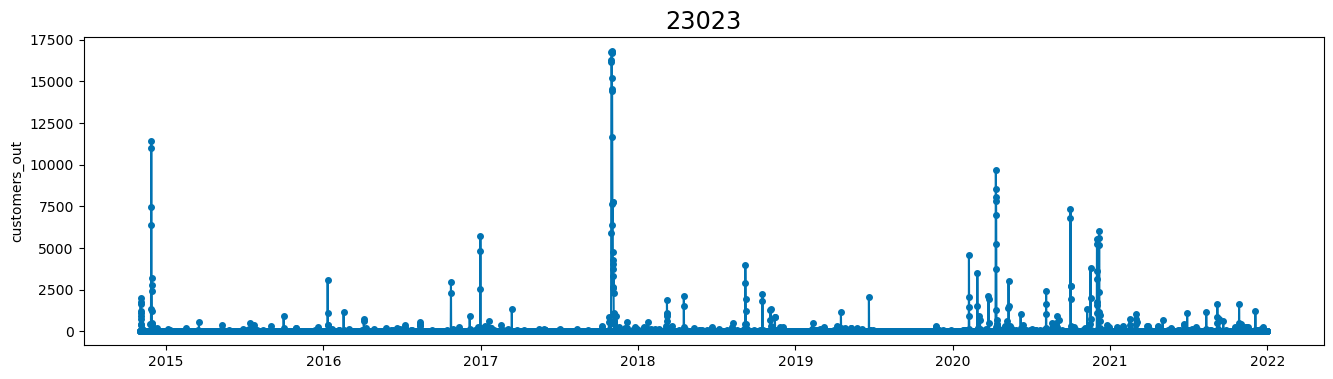

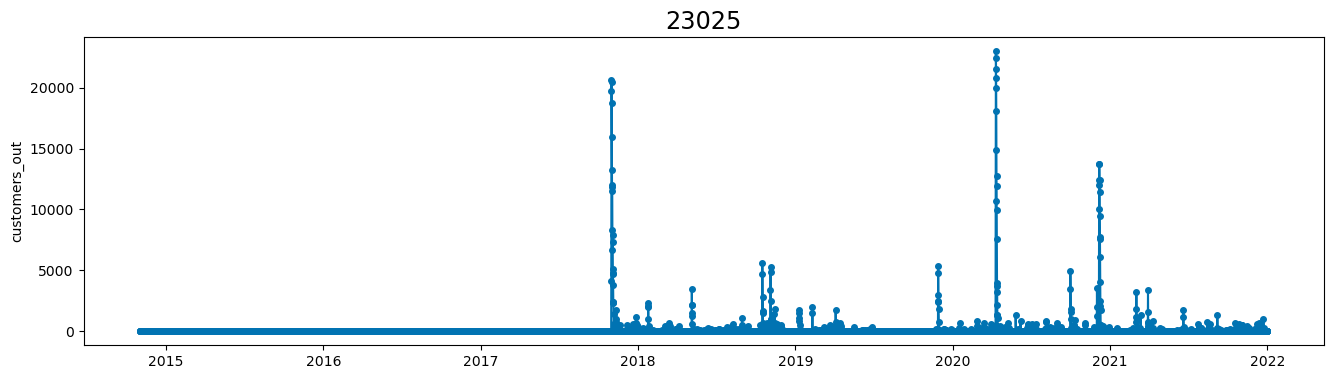

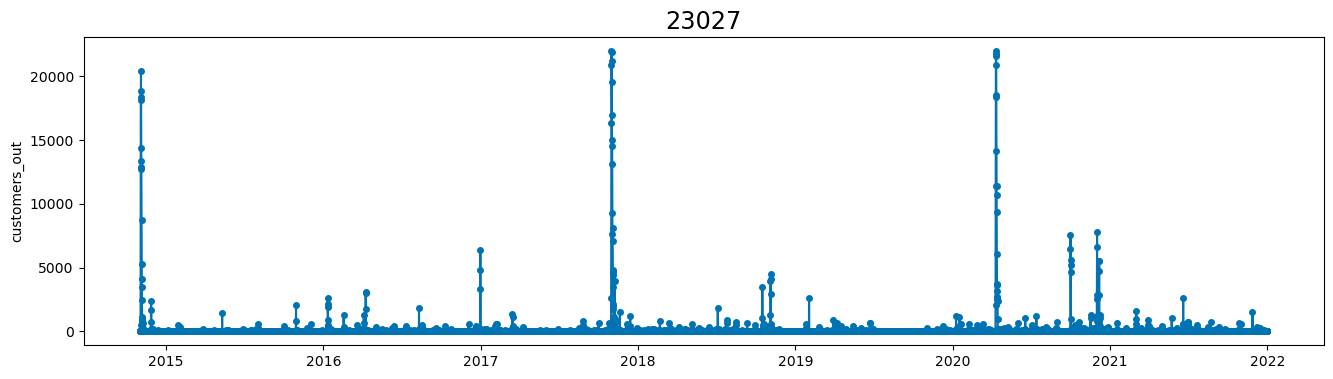

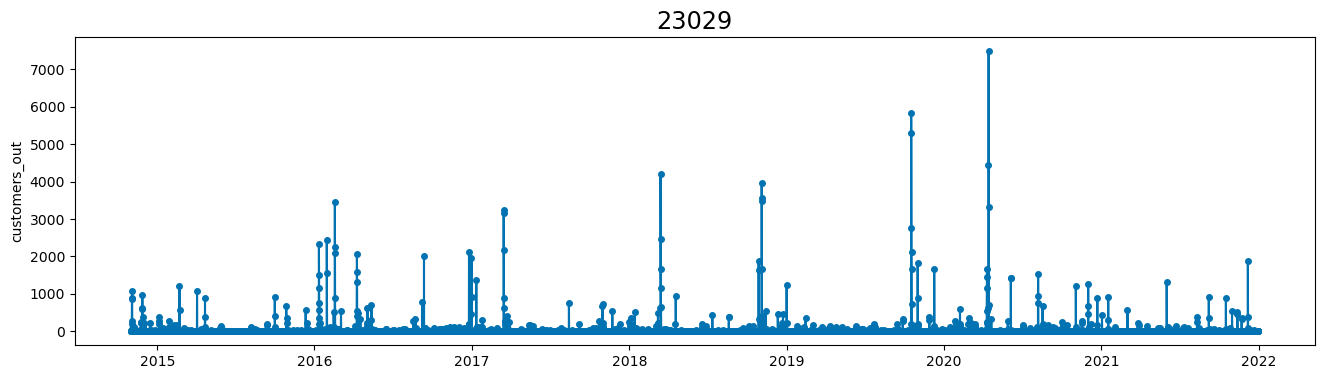

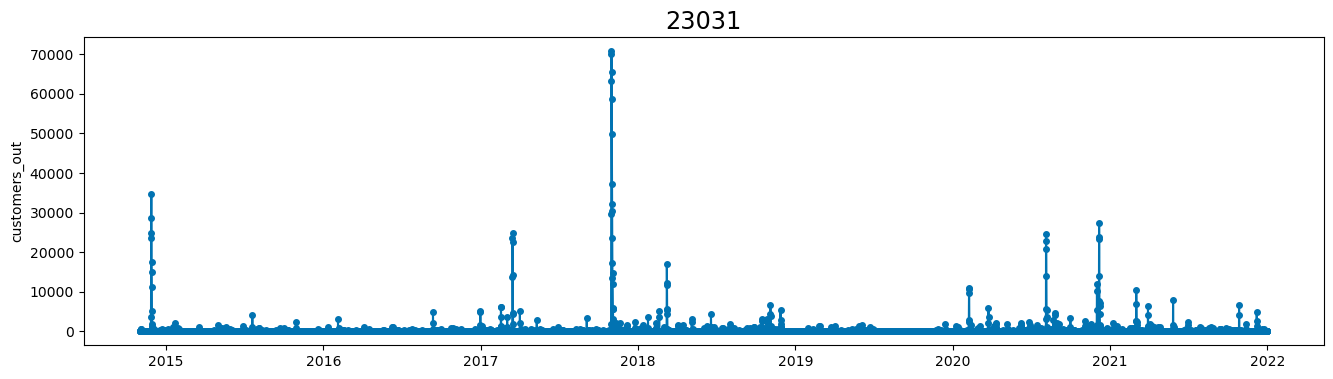

In [12]:
#For each value of fips_code, plot the value of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    plot_series(y_fips, title=fips_code)

## ACF, Stationarity, and PACF plots

We'll make an autocorrelation and partial autocorrelation plot for each of the counties.

The ACF plots suggest that there are correlations with up to 15-20 lags, which corresponds to 4-5 days. There doesn't appear to be any consistent seasonality.

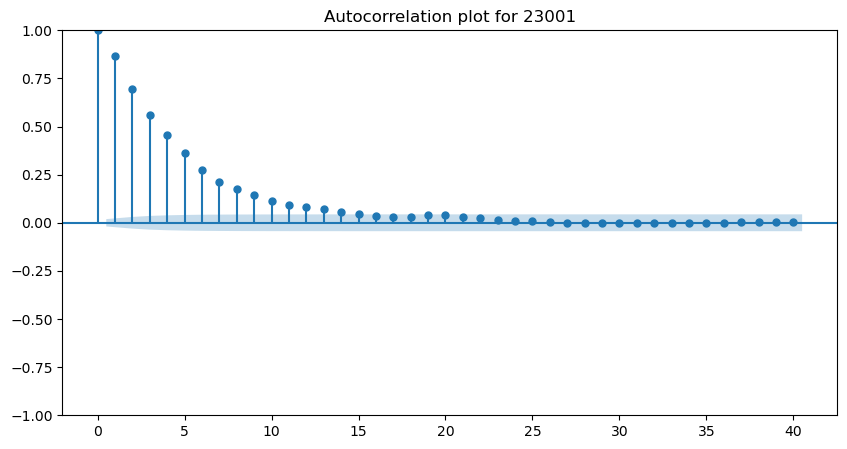

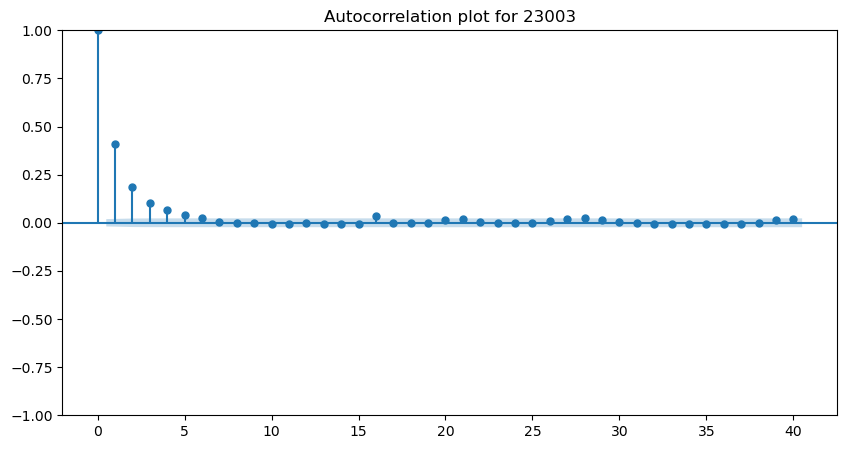

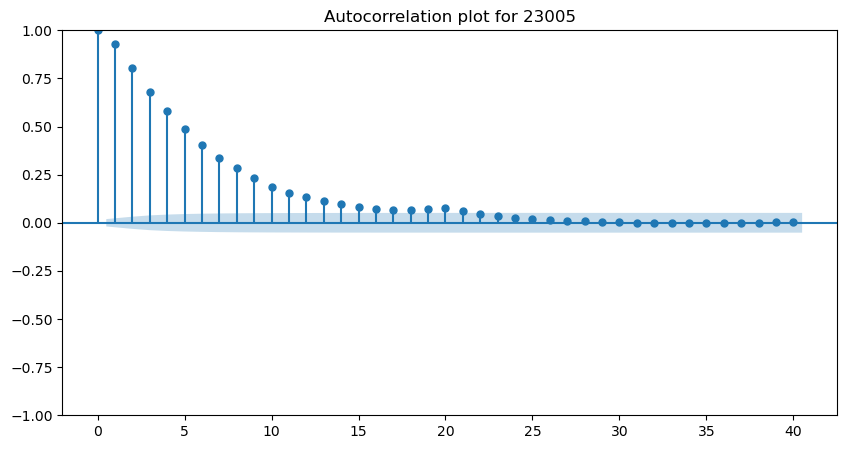

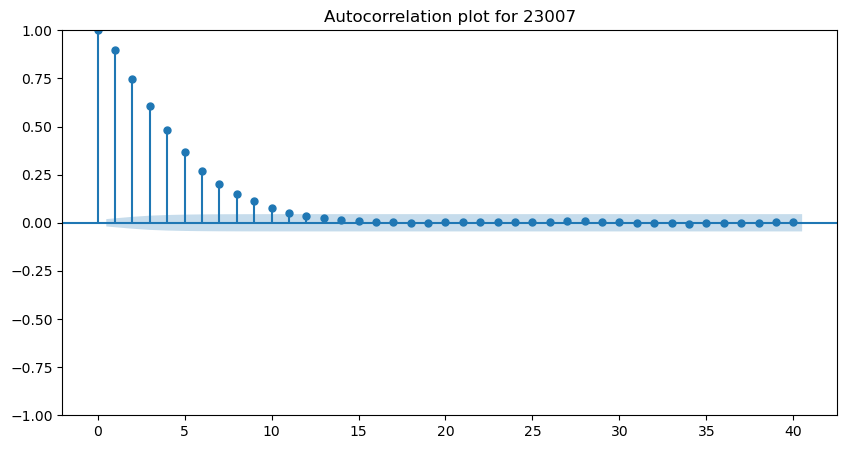

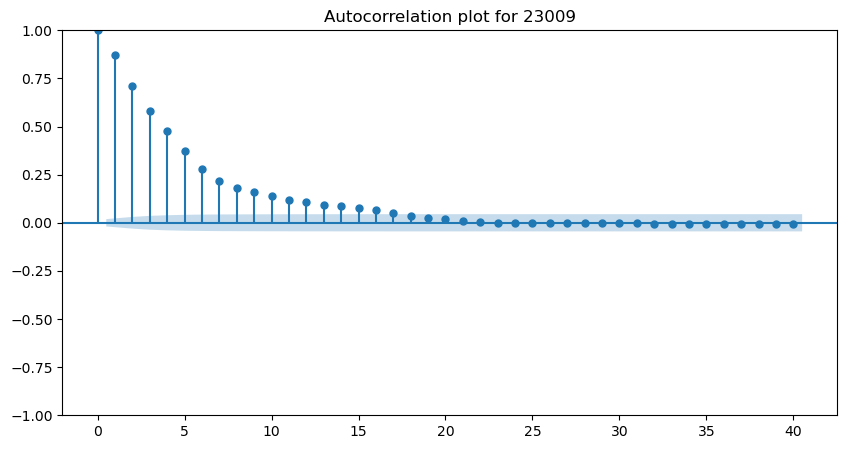

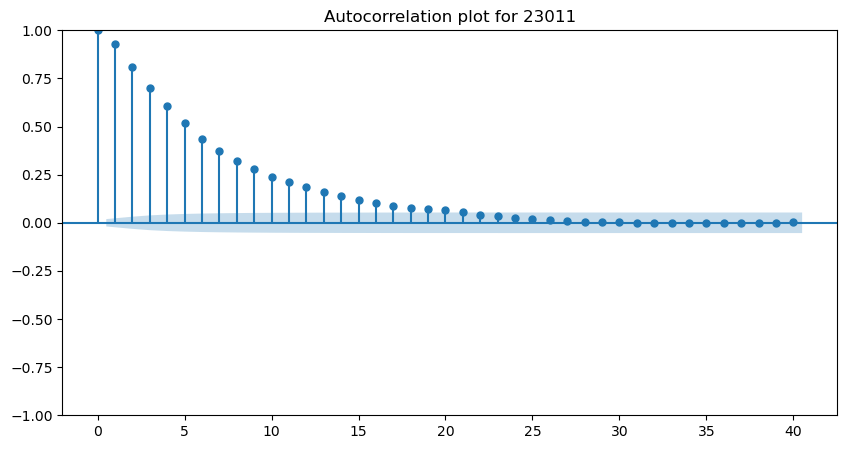

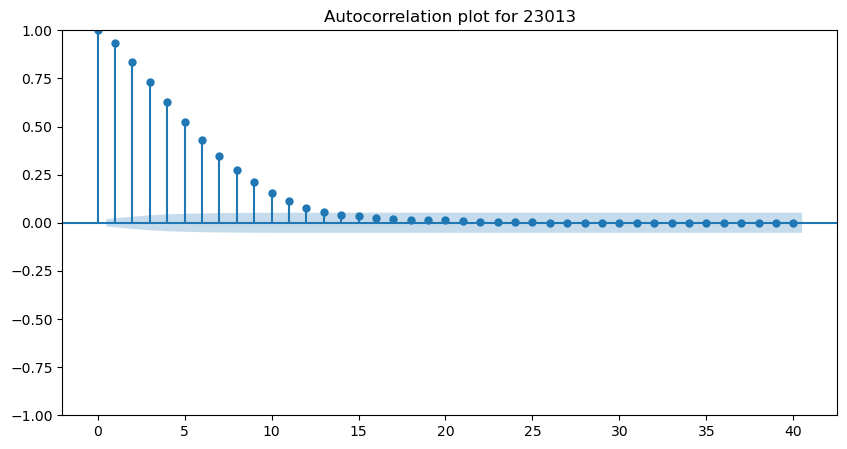

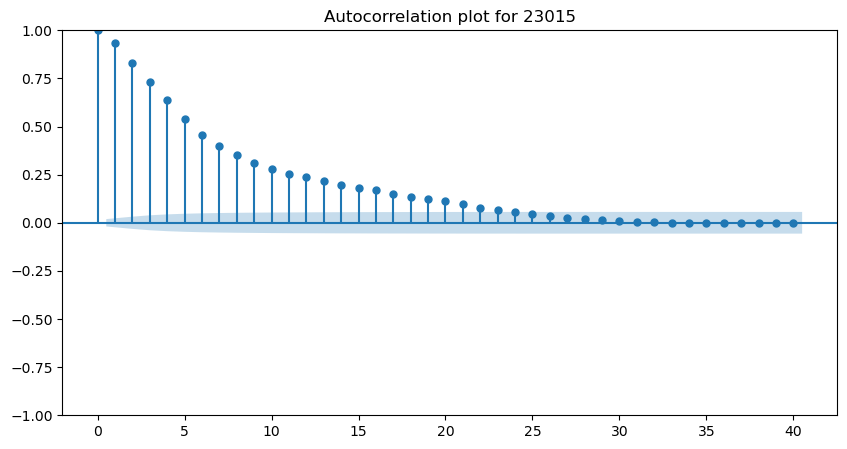

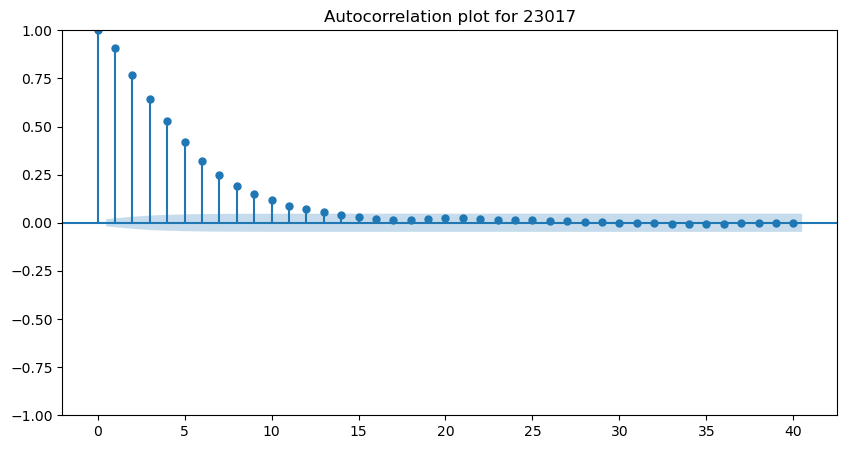

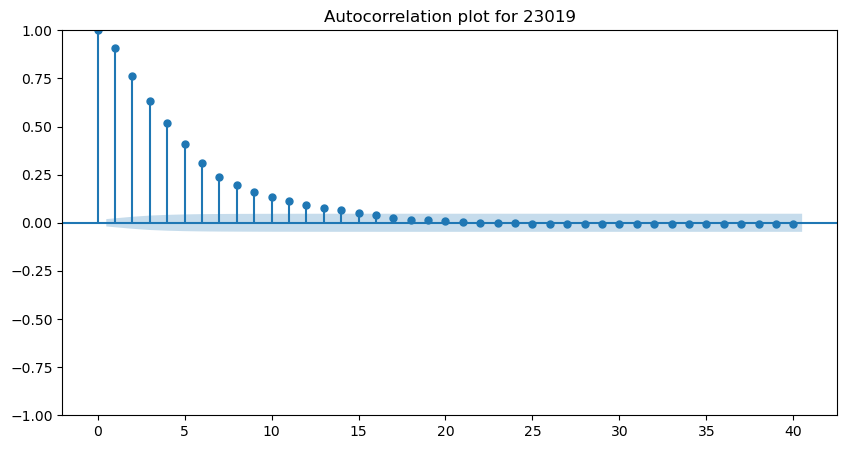

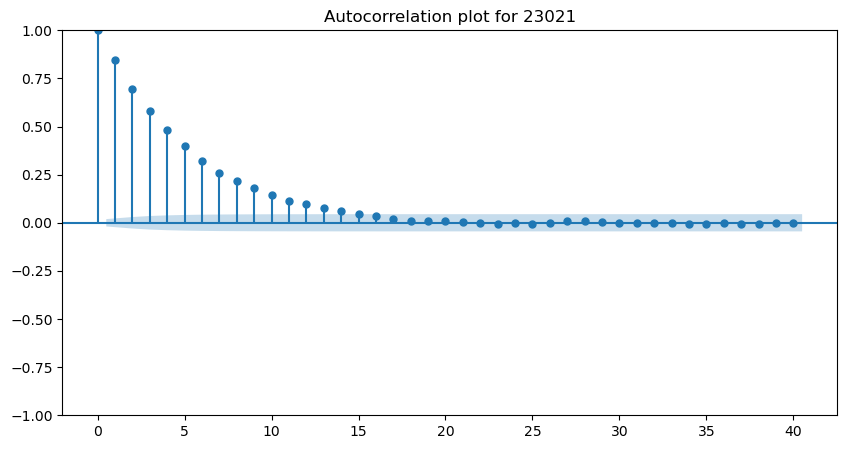

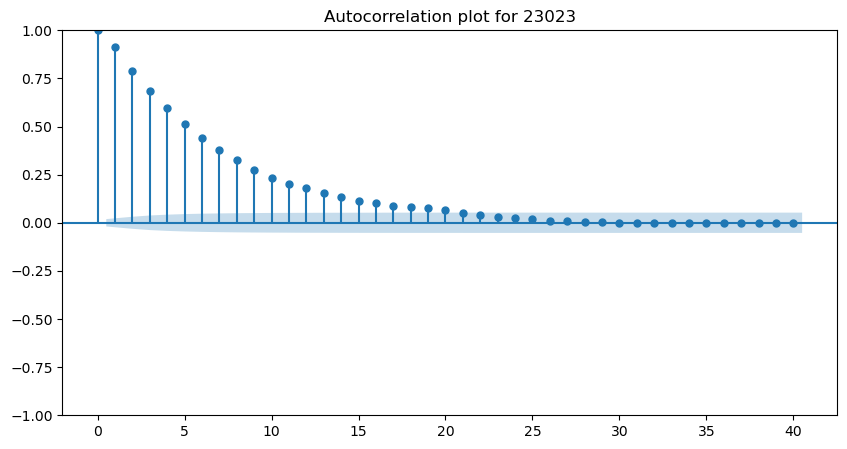

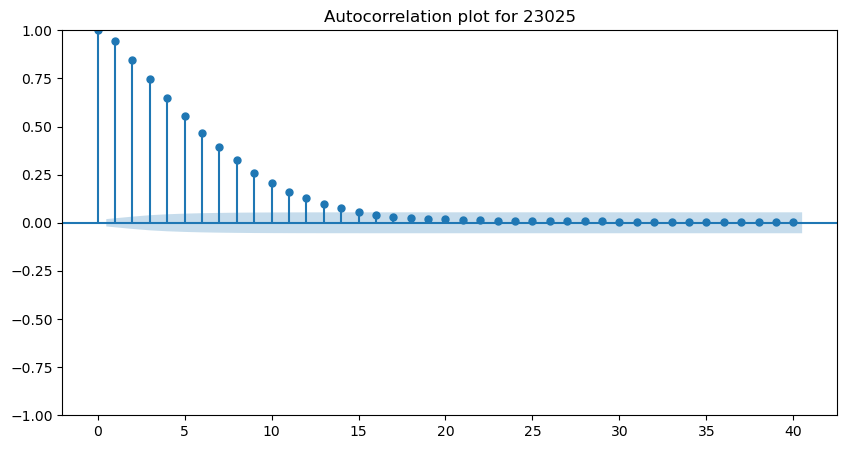

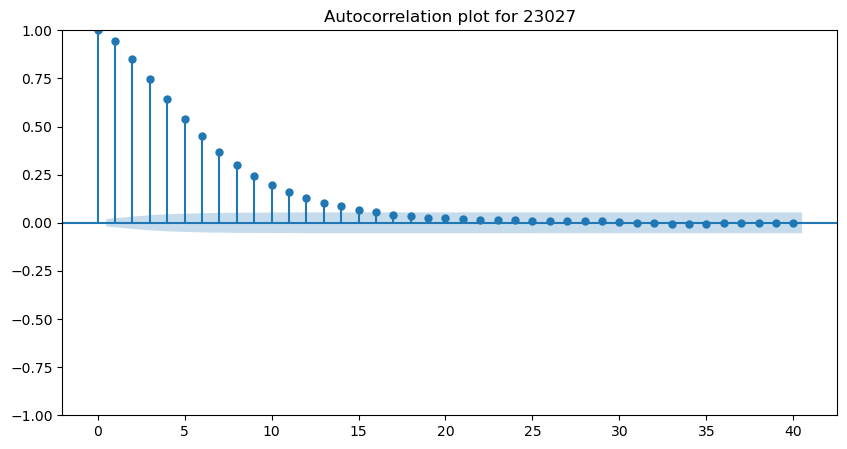

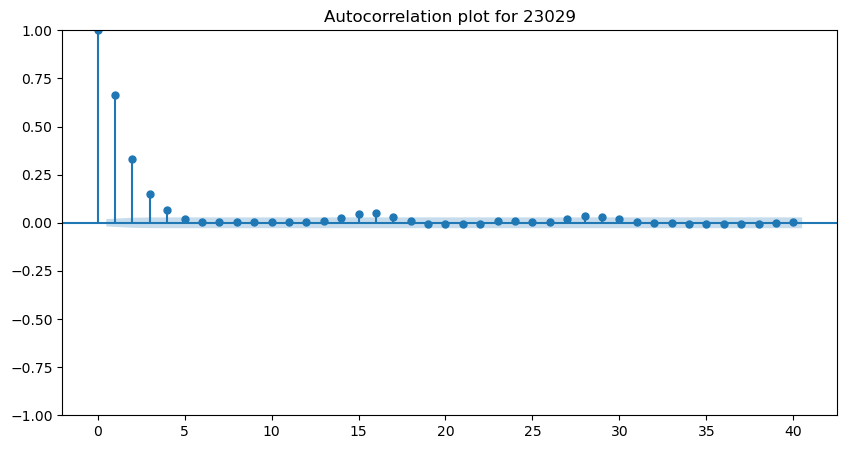

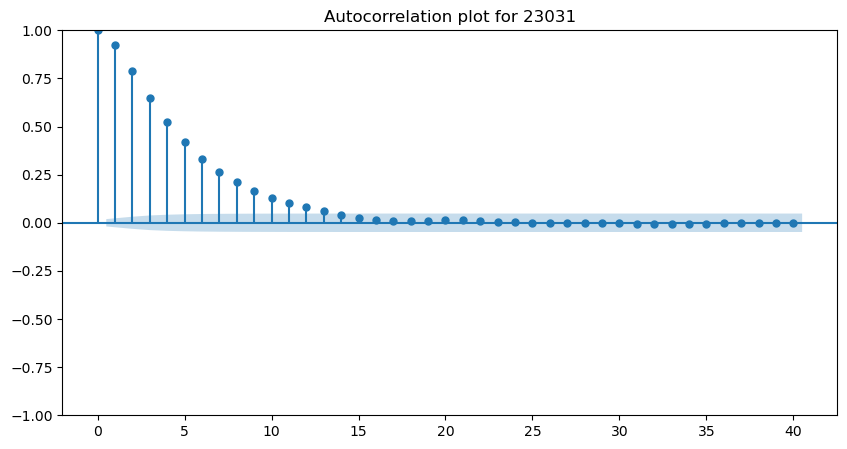

In [14]:
#For each value of fips_code use statsmodels to make an autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    sm.graphics.tsa.plot_acf(y_fips['customers_out'], lags=40, ax=ax)
    plt.title(f'Autocorrelation plot for {fips_code}')
    plt.show()

### Testing for stationarity

We'll use an augmented Dickey-Fuller test. All the p-values are quite tiny, suggesting stationarity.

This suggests that an autoregressive model is appropriate.

In [15]:
# Create a numpy array to hold the fips_codes and p-values
p_values = np.zeros((16, 2))
i=0

#For each value of fips_code, run the Augmented Dickey-Fuller test
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    #sort y_fips
    y_fips = y_fips.sort_index()
    result = sm.tsa.stattools.adfuller(y_fips['customers_out'])
    p_values[i,0]=int(fips_code)
    p_values[i,1]=result[1]
    i=i+1
p_values

array([[2.30010000e+04, 2.02266229e-30],
       [2.30030000e+04, 0.00000000e+00],
       [2.30050000e+04, 1.05219007e-29],
       [2.30070000e+04, 0.00000000e+00],
       [2.30090000e+04, 0.00000000e+00],
       [2.30110000e+04, 2.98314558e-30],
       [2.30130000e+04, 0.00000000e+00],
       [2.30150000e+04, 1.69490413e-29],
       [2.30170000e+04, 0.00000000e+00],
       [2.30190000e+04, 0.00000000e+00],
       [2.30210000e+04, 0.00000000e+00],
       [2.30230000e+04, 1.19006282e-29],
       [2.30250000e+04, 2.18964817e-30],
       [2.30270000e+04, 9.31721772e-29],
       [2.30290000e+04, 0.00000000e+00],
       [2.30310000e+04, 0.00000000e+00]])

### PACF Plots

There is quite a bit of variation from county to county. The first and second lags are statistically significant for all counties. It isn't uncommon for the fourth and fith lags to also be statistically significant. 

This suggests we might use a fifth-order autoregressive model.

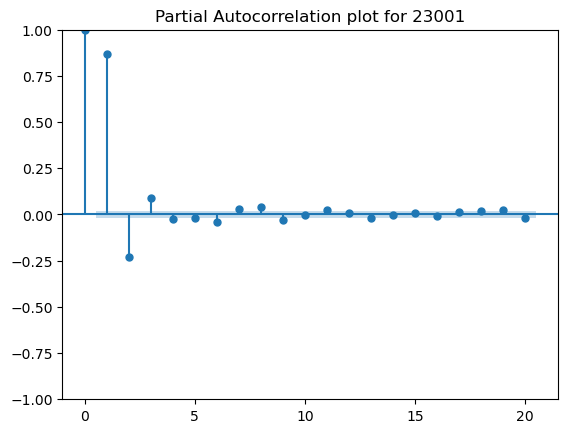

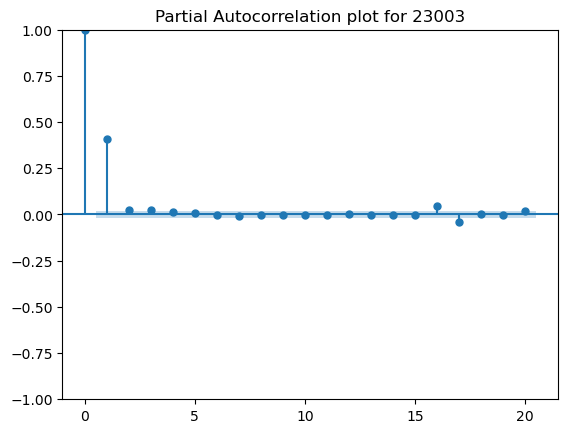

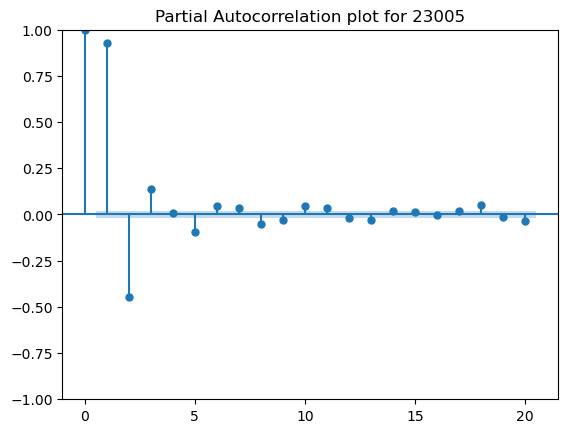

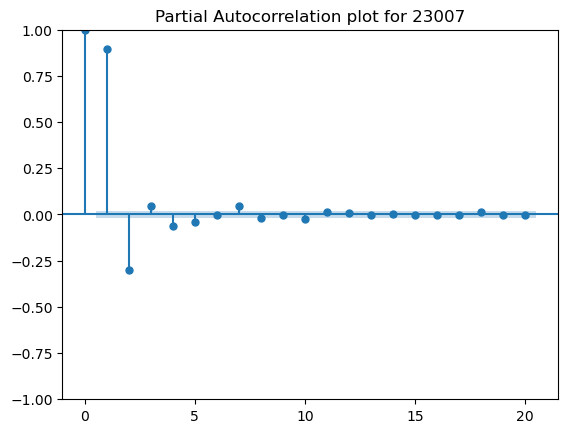

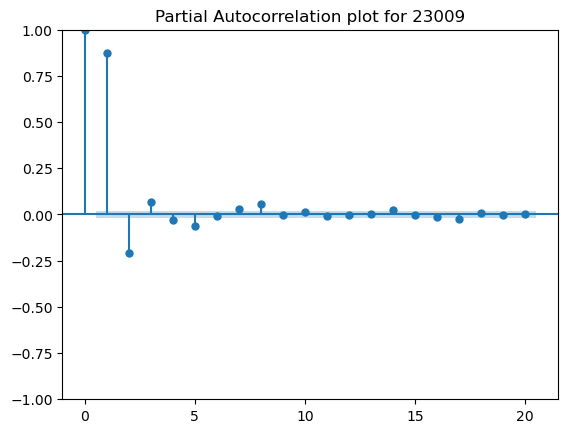

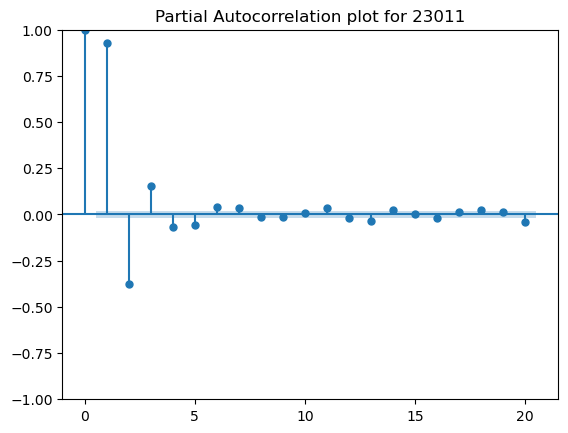

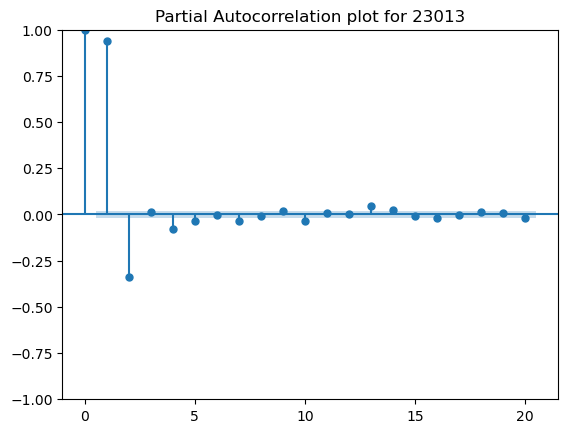

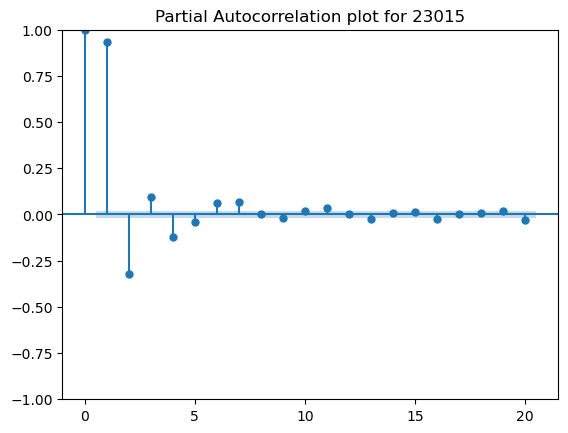

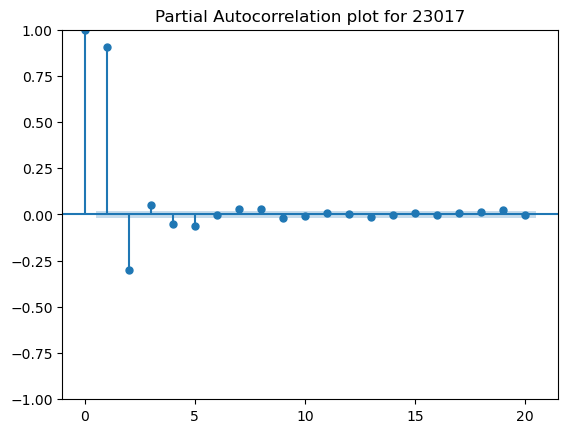

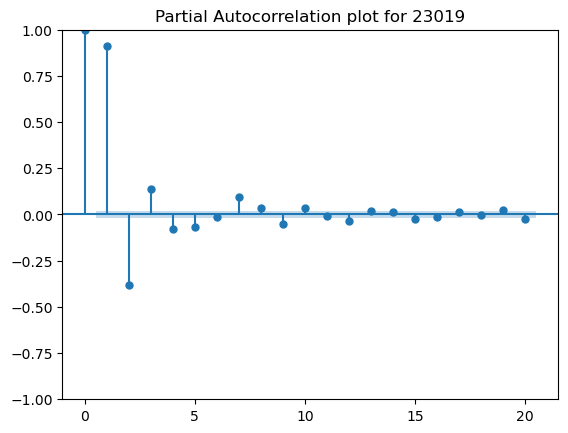

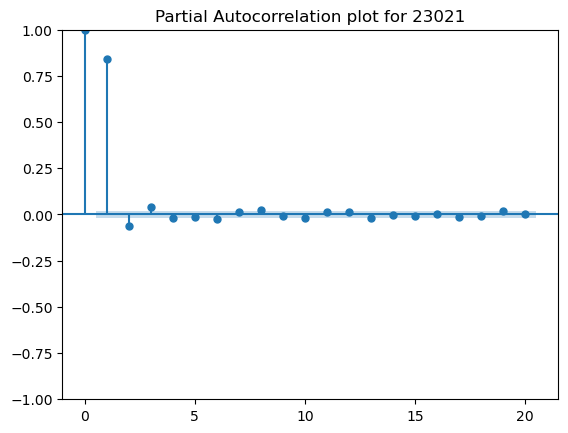

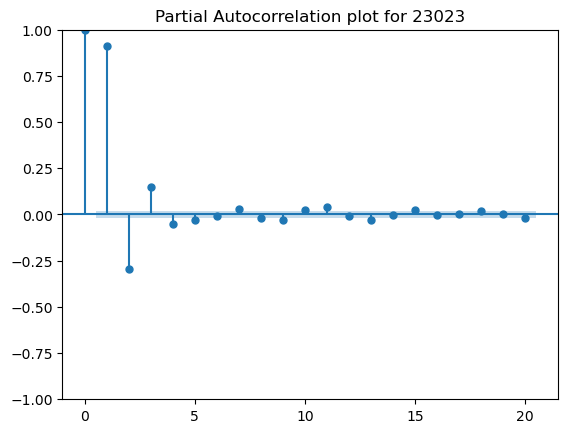

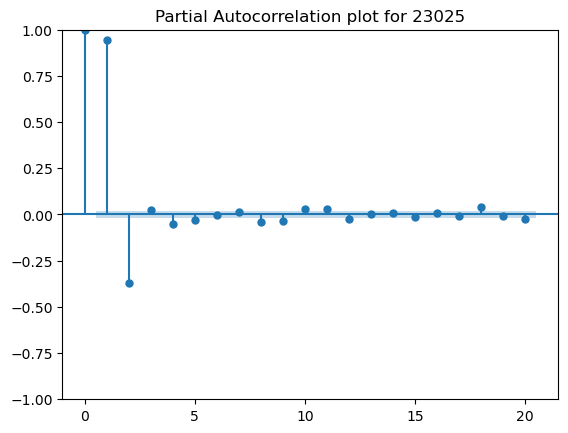

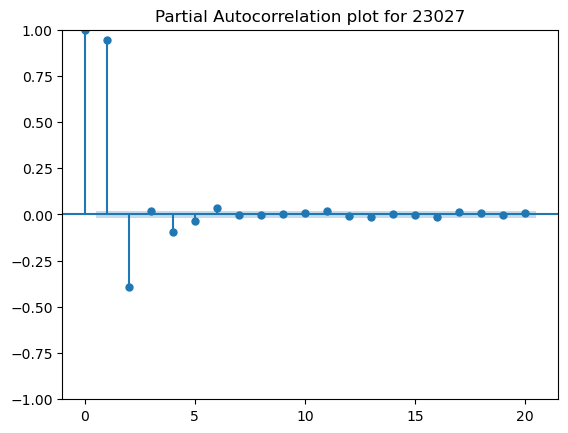

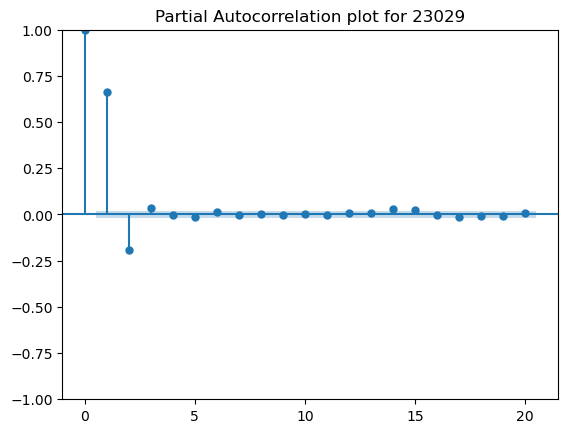

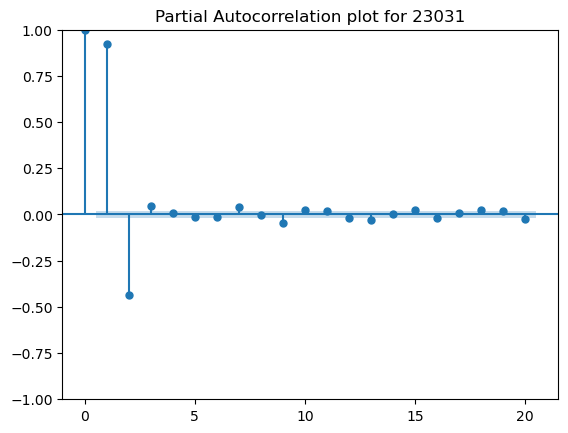

In [16]:
#For each value of fips_code make a partial autocorrelation plot of y
for fips_code in y.index.get_level_values(0).unique():
    y_fips = y.loc[fips_code]
    sm.graphics.tsa.plot_pacf(y_fips, lags=20, method='ols')
    plt.title(f'Partial Autocorrelation plot for {fips_code}')
    plt.show()

# Expanding Window Splitter

In [9]:
# Define the ExpandingWindowSplitter
ews = ExpandingWindowSplitter(
    initial_window=500,      # Length of the initial window
    fh = np.arange(1,5),    # Forecasting horizon
    step_length=4)          # Step length between windows

### Make a plot of the train and test windows

In [29]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import MaxNLocator

def plot_windows(y, train_windows, test_windows, title=""):
    """Visualize training and test windows."""
    simplefilter("ignore", category=UserWarning)

    def get_y(length, split):
        # Create a constant vector based on the split for y-axis."""
        return np.ones(length) * split

    n_splits = len(train_windows)
    n_timepoints = len(y)
    len_test = len(test_windows[0])

    train_color, test_color = sns.color_palette("colorblind")[:2]

    fig, ax = plt.subplots(figsize=plt.figaspect(0.3))

    for i in range(n_splits):
        train = train_windows[i]
        test = test_windows[i]

        ax.plot(
            np.arange(n_timepoints), get_y(n_timepoints, i), marker="o", c="lightgray"
        )
        ax.plot(
            train,
            get_y(len(train), i),
            marker="o",
            c=train_color,
            label="Window",
        )
        ax.plot(
            test,
            get_y(len_test, i),
            marker="o",
            c=test_color,
            label="Forecasting horizon",
        )
    ax.invert_yaxis()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set(
        title=title,
        ylabel="Window number",
        xlabel="Time",
        xticklabels=y.index,
    )
    # remove duplicate labels/handles
    handles, labels = ((leg[:2]) for leg in ax.get_legend_handles_labels())
    ax.legend(handles, labels)

    # Some helper code from sktime

def get_windows(y, cv):
    """Generate windows."""
    train_windows = []
    test_windows = []
    for i, (train, test) in enumerate(cv.split(y)):
        train_windows.append(train)
        test_windows.append(test)
    return train_windows, test_windows

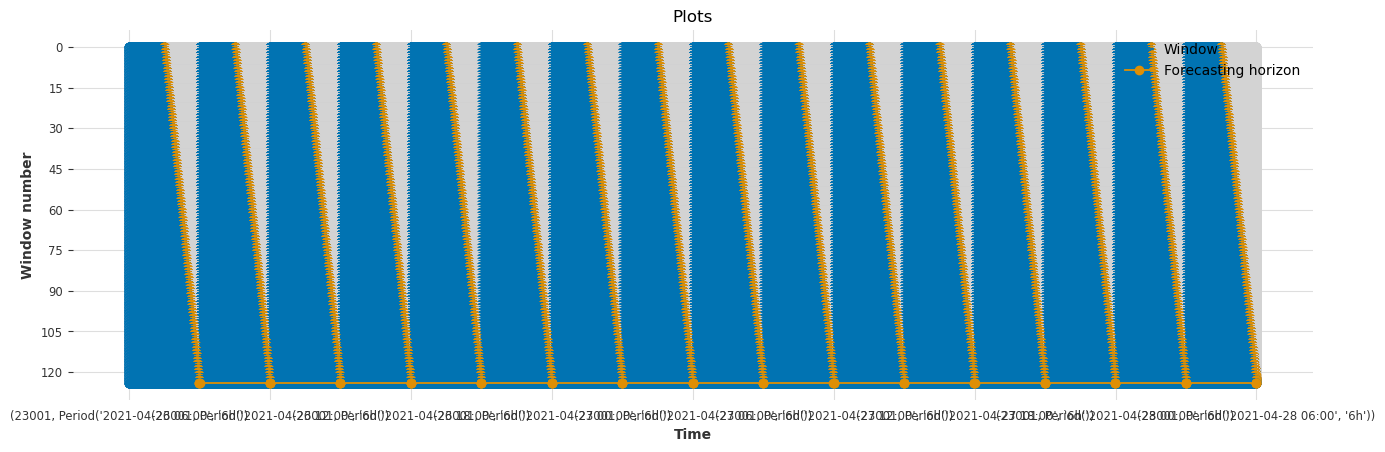

In [78]:
train_windows, test_windows = get_windows(y_small, ews)

plot_windows(y_small, train_windows, test_windows, title="Plots")

# Forecasters

Note that forecasters need to be able to work with panel (or hierarchical) data.

If they don't by default, it is possible to split the data by level and apply the forecaster/regressor at the second level, but they won't (by default) be able to use the entire dataset to generate the model. As the sktime documentation suggests, global forecasting will produce a better fit than one forecaster per time series instance.

### Linear Regression


Note: I'm having trouble getting the lags_past_covariates parameter working. When I include it, I get an error that past_covariates=None in the fit command. I suspect this might have something to do with the different ways Darts and sktime use the fit command, although I also tried setting this up directly from the Darts library and things still didn't quite work....

In [ ]:
# Initialize the DartsLR Model
dartslr = DartsLinearRegressionModel(
    lags=20,
#    lags_past_covariates=20, # Including this produces an error in the evaluate function... 
    output_chunk_length=4
)

# Make
pipe_lr = ForecastingPipeline(steps=[
    ("scaler", TabularToSeriesAdaptor(StandardScaler())),
    ("forecaster", dartslr),
])


# In case the forecasting pipeline doesn't work, we can also try setting this up with a regressor pipeline
#scaler = TabularToSeriesAdaptor(StandardScaler())

#regressor_pipeline_knn = RegressorPipeline(
#    regressor=dartslr,
#    transformers=[scaler]
#)

y_small = y_small.rename(columns={"customers_out": "c0"})

### XGBoost

https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.forecasting.darts.DartsXGBModel.html

Note that the set_config method can be used to set up parallelization

In [ ]:
# Initialize the DartsXGBModel
# This is just a guess at what the hyperparameters should be...
dartsxgb = DartsXGBModel(
    lags=20,
    #lags_past_covariates=20, # Including this produces an error in the evaluate function... 
    output_chunk_length=4,
    kwargs={
        "n_estimators": 100,
        "max_depth": 3,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
    }
)

#In y_small rename customers_out as c0 for compatibility with the output of the xgb predictor
y_small = y_small.rename(columns={"customers_out": "c0"})

## Evaluate the forecasters for customers_out using evaluate

This uses the built-in evaluate function. But it can (I think) only evaluate point-by point, rather than evaluating over an aggregate of the output(?)

Keeping these here for future reference - particularly if we can aggregate and compute the max.

In [ ]:
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

results_lr_e = evaluate(
    forecaster=pipe_lr,
    cv=ews,
    y=y_small,
    X=X_small,             # This works with exogeneous variables; predictions are made using predict/predict_proba, or predict_quantiles depending on scoring
    strategy="refit",  # Options are "update" and "refit" (which will reset and fit forecaster via fit), verses updating forecaster via "update"
    scoring=MeanSquaredError(square_root = True),       # None defaults to MeanAbsolutePercentageError(symmetric=True). Options at: https://www.sktime.net/en/stable/api_reference/performance_metrics.html
    return_data=True,   # True means it returns three pd.Series columns for y_train, y_pred, and y_test
    error_score="raise",
    backend=None       # (default is None) Parallelization backend; runs parallel evaluate if specified and strategy="refit"; recommendation to use "dask" or "loky"
)

In [24]:
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

results_xgb_e = evaluate(
    forecaster=dartsxgb,
    cv=ews,
    y=y_small,
    X=X_small,             # This works with exogeneous variables; predictions are made using predict/predict_proba, or predict_quantiles depending on scoring
    strategy="refit",  # Options are "update" and "refit" (which will reset and fit forecaster via fit), verses updating forecaster via "update"
    scoring=MeanSquaredError(square_root = True),       # None defaults to MeanAbsolutePercentageError(symmetric=True). Options at: https://www.sktime.net/en/stable/api_reference/performance_metrics.html
    return_data=True,   # True means it returns three pd.Series columns for y_train, y_pred, and y_test
    error_score="raise",
    backend=None       # (default is None) Parallelization backend; runs parallel evaluate if specified and strategy="refit"; recommendation to use "dask" or "loky"
)

<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 216 from C header, got 232 from PyObject


### Plot the results vs actuals for the first window

Not very good!

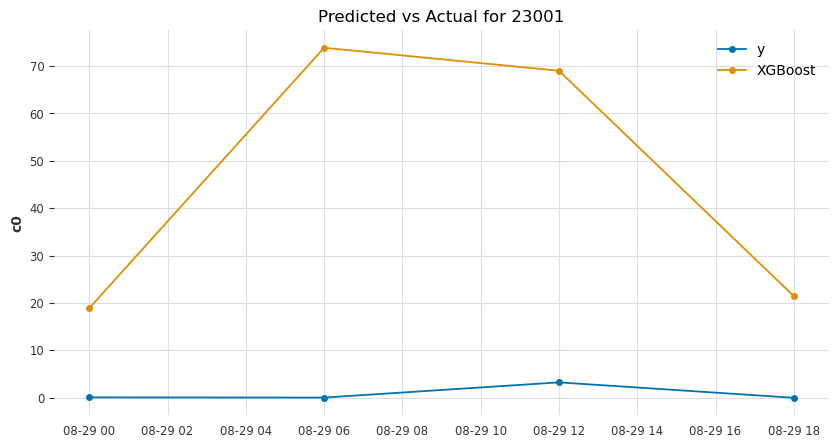

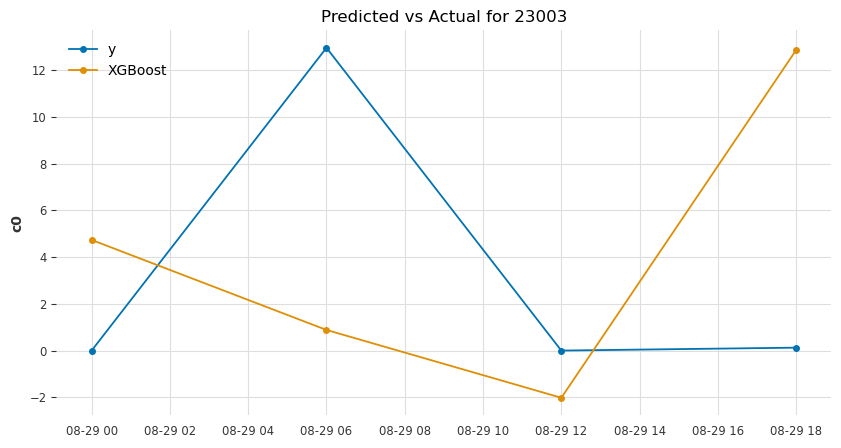

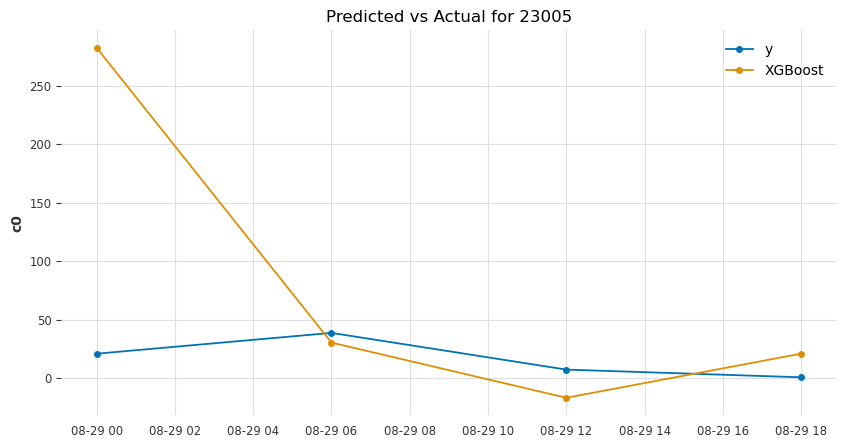

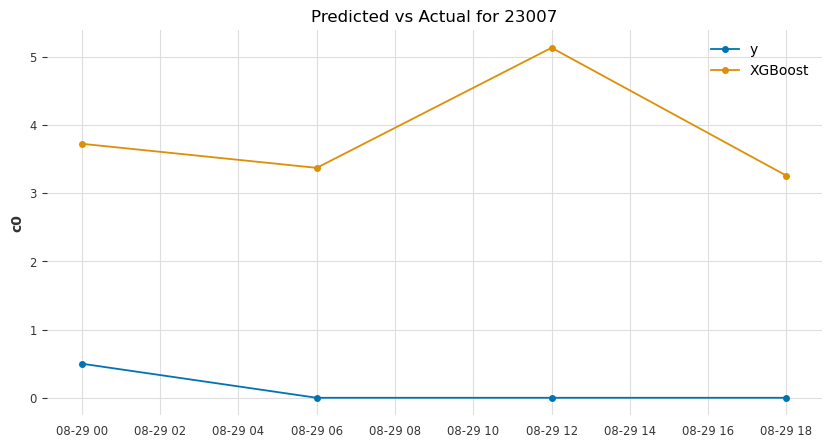

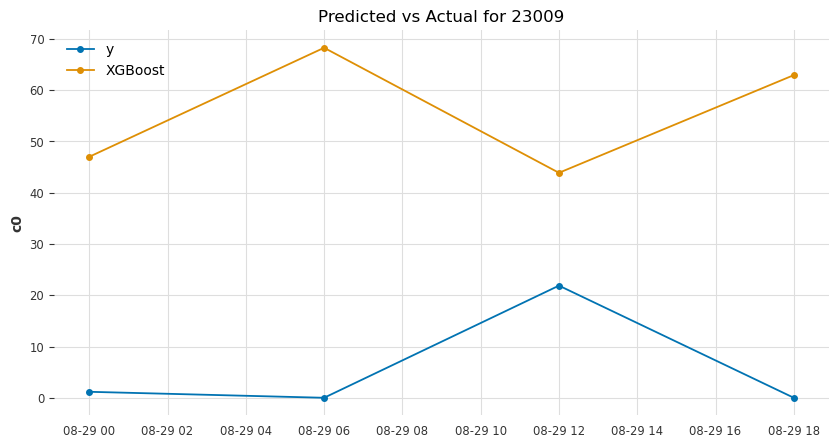

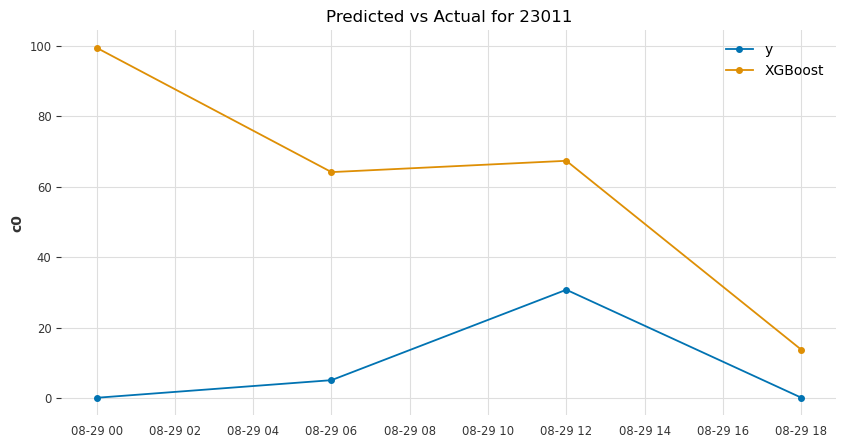

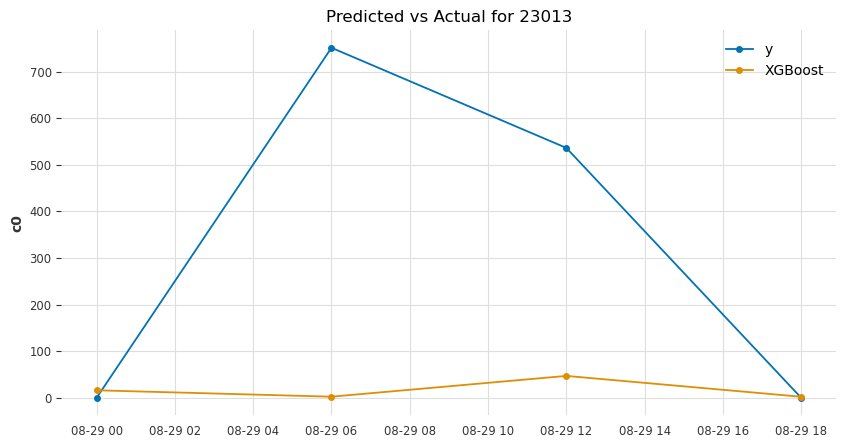

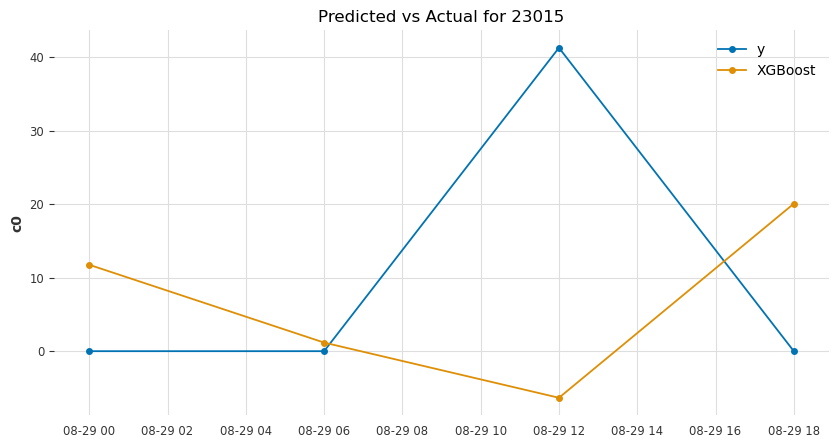

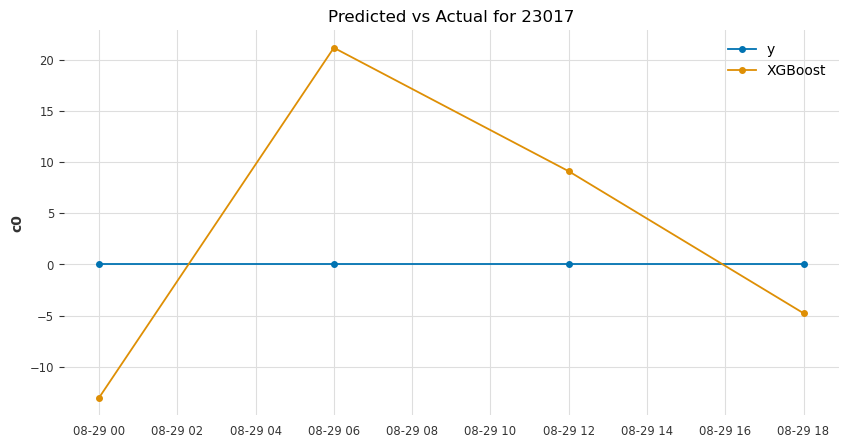

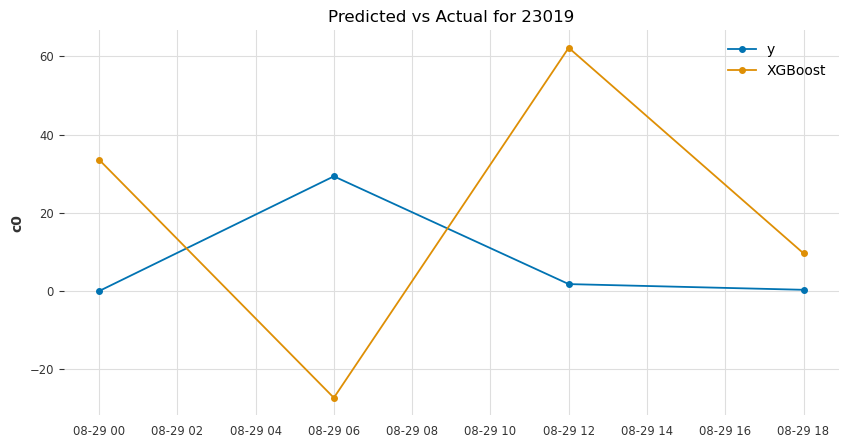

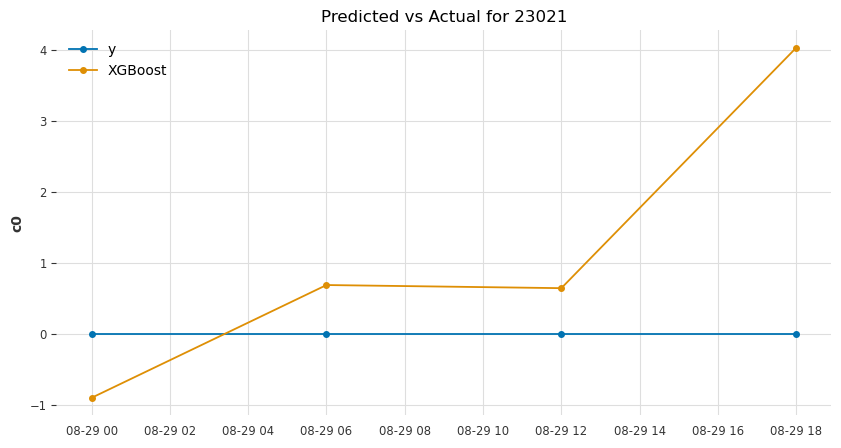

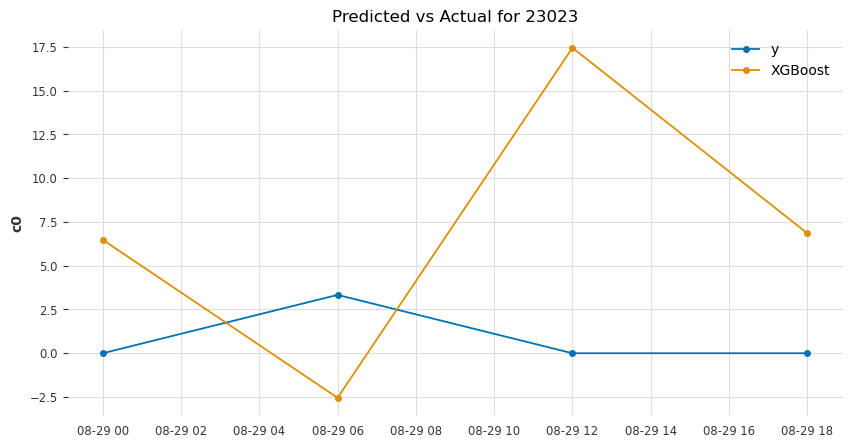

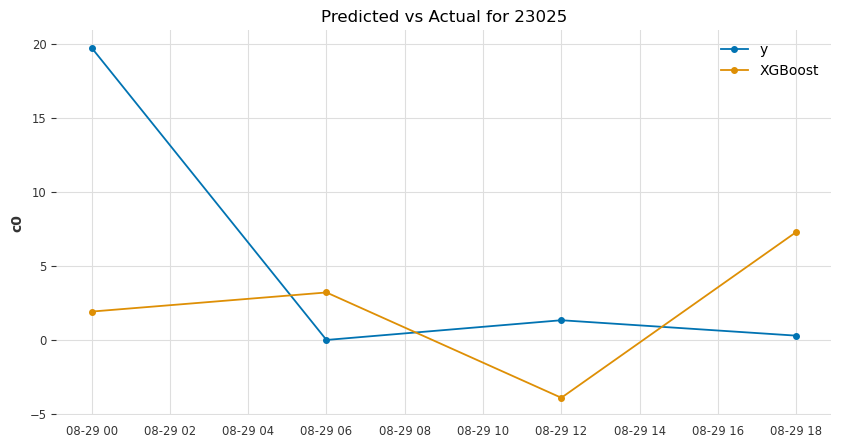

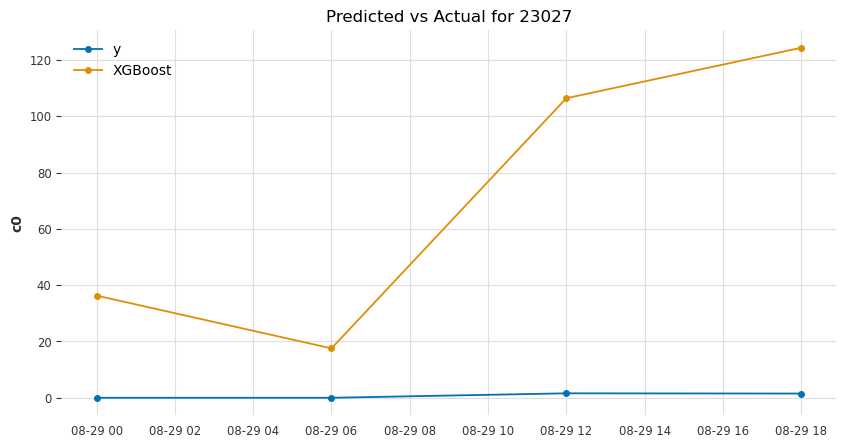

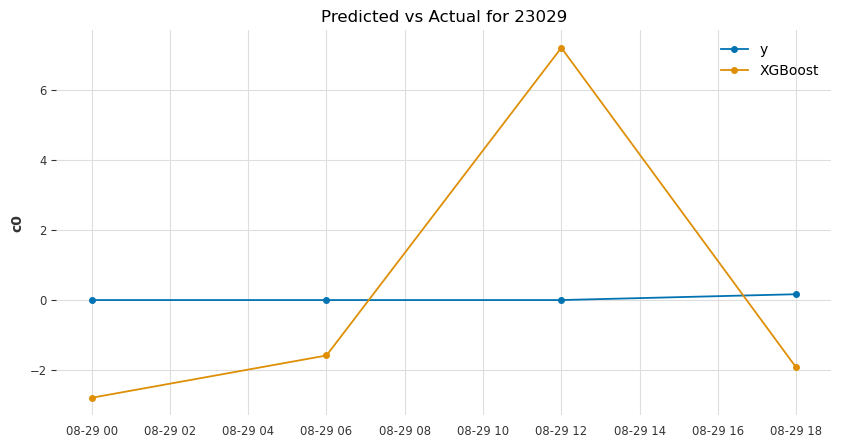

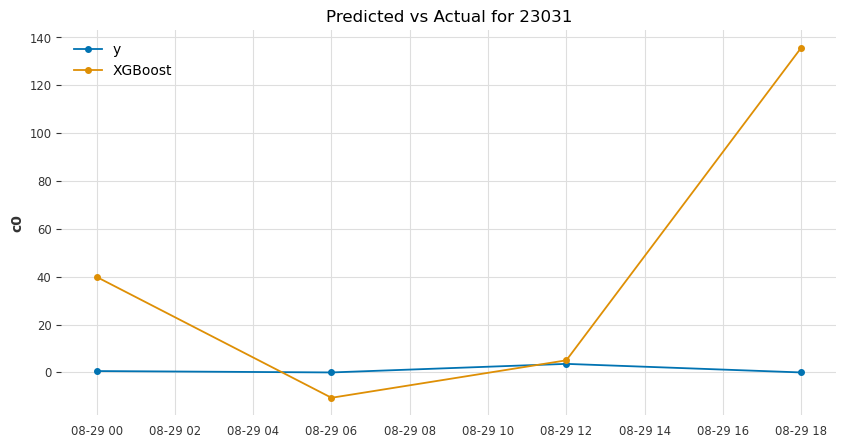

In [29]:
# Make a plot of results.y_test[0] and results.y_pred[0] for each value of fips_code
for fips_code in y.index.get_level_values(0).unique():
    y_test_fips = results_xgb_e.y_test[0].loc[fips_code]
    y_pred_fips = results_xgb_e.y_pred[0].loc[fips_code]
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))
    plot_series(y_test_fips, y_pred_fips, labels=["y", "XGBoost"], ax=ax)
    plt.title(f'Predicted vs Actual for {fips_code}')
    plt.show()

### Evaluate performance

Not so hot!

In [28]:
results_lr_e.test_MeanSquaredError

0      48.624511
1      28.034703
2      29.370645
3      32.556680
4      85.664814
         ...    
120    32.146668
121    47.904226
122    29.487495
123    29.768189
124    29.072509
Name: test_MeanSquaredError, Length: 125, dtype: float64

In [30]:
results_xgb_e.test_MeanSquaredError

0      63.930754
1      45.095237
2      43.152405
3      59.566402
4      87.982598
         ...    
120    51.763159
121    53.169544
122    54.475818
123    34.907944
124    43.727588
Name: test_MeanSquaredError, Length: 125, dtype: float64

## Manual Evaluation

### Linear Regression

Note: Currently this just outputs an array of RMSE values. But it would be easy enough to get it to also output the predicted and actual values for each split

In [ ]:
#Use sw to make predictions of max values for y_small
mse = MeanSquaredError(square_root = True)

#n_splits = ews.get_n_splits(y_small)

results_lr_manual = []

i=0
for train_idx, test_idx in ews.split(y_small):
    # Split the data
    y_small_train, y_small_test, X_small_train, X_small_test = y_small.iloc[train_idx], y_small.iloc[test_idx], X_small.iloc[train_idx], X_small.iloc[test_idx]

    # Fit the model
    pipe_lr.fit(y=y_small_train, X=X_small_train)

    # Predict
    # Note: I'm not sure how to restrict this prediction to just the past 20 lags...
    y_small_pred = pipe_lr.predict(4, X=X_small_test)
    
    # Compute the maximum values of y for each fips code
    y_small_pred_max = y_small_pred.groupby(level=0).max()
    y_small_test_max = y_small_test.groupby(level=0).max()

    rmse = mse(y_small_pred_max, y_small_test_max)

    # Store the results
    results_lr_manual.append((i, rmse))
    i=i+1

In [12]:
results_lr_manual

[(0, 185.55581410821958),
 (1, 26.09833286452709),
 (2, 31.404139327745764),
 (3, 81.08048450511292),
 (4, 238.63538652456415),
 (5, 33.24766435333798),
 (6, 128.17507683626948),
 (7, 29.570591487495786),
 (8, 680.4303121179269),
 (9, 453.37261973413945),
 (10, 57.58745745092898),
 (11, 58.936907402190386),
 (12, 2297.2662848876184),
 (13, 370.1365392560779),
 (14, 196.40818185358583),
 (15, 133.04017792181818),
 (16, 182.95512718704083),
 (17, 437.956286978457),
 (18, 477.2992409130644),
 (19, 42.44799568818795),
 (20, 61.13661834977609),
 (21, 162.96742035818454),
 (22, 177.14178684830495),
 (23, 61.615478872644616),
 (24, 19.60201616890764),
 (25, 46.40832920228273),
 (26, 158.23329489630916),
 (27, 340.2710540332814),
 (28, 187.0590919968619),
 (29, 39.39214095266436),
 (30, 35.620389637850295),
 (31, 28.992853085257945),
 (32, 42.78682882096489),
 (33, 31.179823806131676),
 (34, 1623.7887401342043),
 (35, 255.7418968644913),
 (36, 177.52639320109543),
 (37, 59.32939746807029),
 (3

### XGBoost

In [ ]:
#Use sw to make predictions of max values for y_small
mse = MeanSquaredError(square_root = True)
fh = np.arange(1, 13)

n_splits = ews.get_n_splits(y_small)

results_kgb_manual = []

i=0
for train_idx, test_idx in ews.split(y_small):
    # Split the data
    y_small_train, y_small_test, X_small_train, X_small_test = y_small.iloc[train_idx], y_small.iloc[test_idx], X_small.iloc[train_idx], X_small.iloc[test_idx]

    # Fit the model
    dartsxgb.fit(y_small_train, X_small_train, ews.fh)
    
    # Predict
    y_small_pred = dartsxgb.predict(ews.fh, X_small_test)
    
    # Compute the maximum values of y for each fips code
    y_small_pred_max = y_small_pred.groupby(level=0).max()
    y_small_test_max = y_small_test.groupby(level=0).max()

    rmse = mse(y_small_pred_max, y_small_test_max)

    # Store the results
    results_kgb_manual.append((i, rmse))
    i=i+1

In [83]:
results

[(0, 193.95515666049155),
 (1, 96.02287342478387),
 (2, 121.12729273906953),
 (3, 162.71003705958523),
 (4, 222.47854337999124),
 (5, 49.93392792646751),
 (6, 114.84377272703718),
 (7, 205.06625077909175),
 (8, 692.5905492450883),
 (9, 397.7185037820167),
 (10, 555.9842706629338),
 (11, 98.5545181266537),
 (12, 2304.013379090579),
 (13, 432.3468139267183),
 (14, 230.10224871527055),
 (15, 337.9844579615142),
 (16, 260.4518903469538),
 (17, 424.72192675122534),
 (18, 417.4296859447211),
 (19, 455.88118872382853),
 (20, 106.80785502196709),
 (21, 185.59272243144585),
 (22, 131.4445300439263),
 (23, 94.70162098886496),
 (24, 2059.037226573891),
 (25, 83.61759341685561),
 (26, 156.64890310022903),
 (27, 322.97894003857306),
 (28, 193.16229808486807),
 (29, 162.63050286913165),
 (30, 125.59735918682502),
 (31, 117.96131265009274),
 (32, 136.74127293844384),
 (33, 158.98233855451022),
 (34, 1618.2541028337898),
 (35, 240.74112824392807),
 (36, 325.0572404916223),
 (37, 218.72066330221264),
 

# Old Code

### An attempt at a KNN Forecaster

In [ ]:
# Note that KNN and RF aren't, by default, built to handle hierarchical data

#It is possible to vectorize/up-cast them

from sktime.utils._testing.hierarchical import _make_hierarchical

y = _make_hierarchical()

# Set up a KNN Regressor for time series using 10 neighbors
regressor_knn = KNeighborsTimeSeriesRegressor(
    n_neighbors=10,
    weights='uniform',
    algorithm='brute',
    distance='dtw',
    leaf_size=30,
    n_jobs=None     # This can be set higher to enable parallel processing; see sktime docs for more info
    )

#forecaster_knn = make_reduction(regressor_knn, window_length=15, strategy="recursive")

scaler = TabularToSeriesAdaptor(StandardScaler())

#pipe_X = ForecastingPipeline(steps=[
#    ("scaler", scaler),
#    ("forecaster", forecaster_knn),
#])

# Set up a RegressorPipeline with a StandardScaler and the regressor_knn
regressor_pipeline_knn = RegressorPipeline(
    regressor=regressor_knn,
    transformers=[scaler]
)




### An attempt at a random forest

Note that TimeSeriesForestRegressor is documented:
https://www.sktime.net/en/latest/api_reference/auto_generated/sktime.regression.interval_based.TimeSeriesForestRegressor.html (but doesn't accept panel data)

And here:
https://arxiv.org/pdf/1302.2277

There is some code to directly adapt RF to panel data here:
https://www.sktime.net/en/latest/examples/01c_forecasting_hierarchical_global.html
(but it's a bit tricky to follow)

In [ ]:
# Set up a random forest for time series
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sktime.forecasting.compose import make_reduction
from sktime.transformations.series.date import DateTimeFeatures
from sktime.forecasting.base import ForecastingHorizon
from sktime.forecasting.compose import ForecastingPipeline
from sktime.transformations.series.summarize import WindowSummarizer

kwargs = {
    "lag_feature": {
        "lag": [1],
        "mean": [[1, 3], [3, 6]],
        "std": [[1, 4]],
    }
}

transformer = WindowSummarizer(**kwargs)
y_transformed = transformer.fit_transform(y_train)

regressor_rf = make_pipeline(
    RandomForestRegressor(random_state=1),
)

# Set up a random forest for time series
#regressor_rf = TimeSeriesForestRegressor(
#    min_interval=3,
#    n_estimators=200,
#    n_jobs=None        # This can be set higher to enable parallel processing; see sktime docs for more info
#    )